In [1]:
import numpy as np
import matplotlib.pyplot as plt

def perceptron(inputs, weights, bias):
    """Calculates the output of a single perceptron utilizing a step activation function."""
    assert len(inputs) == len(weights), "Dimensionality mismatch between inputs and weights."

    # Calculate the weighted sum using the dot product
    weighted_sum = np.dot(inputs, weights) + bias

    # --- YOUR CODE HERE --- #
    # Apply the step activation function:
    # If weighted_sum is greater than or equal to 0, output 1
    # Otherwise, output 0
    # --- END YOUR CODE --- #

# Test functionality
test_inputs =[1, 0]
test_weights = [0.5, 0.5]
test_bias = -0.7
print(f"Test Output: {perceptron(test_inputs, test_weights, test_bias)}")

Test Output: None


In [2]:
def perceptron(inputs, weights, bias):
    weighted_sum = np.dot(inputs, weights) + bias
    if weighted_sum >= 0:
        return 1
    else:
        return 0

In [4]:
gate_inputs = [[0, 0], [0, 1],[1, 0], [1, 1]]

# --- YOUR TASK: Define weights and bias for OR --- #
weights_or = [1, 1]
bias_or = -0.5
# --- END YOUR TASK --- #

print("--- OR Gate Output ---")
for input_pair in gate_inputs:
    output = perceptron(input_pair, weights_or, bias_or)
    print(f"Input: {input_pair}, Output: {output}")

--- OR Gate Output ---
Input: [0, 0], Output: 0
Input: [0, 1], Output: 1
Input: [1, 0], Output: 1
Input: [1, 1], Output: 1


In [6]:
# --- YOUR TASK: Define weights and bias for AND --- #
weights_and = [0.5, 0.5]
bias_and = -0.7
# --- END YOUR TASK --- #

print("--- AND Gate Output ---")
for input_pair in gate_inputs:
    output = perceptron(input_pair, weights_and, bias_and)
    print(f"Input: {input_pair}, Output: {output}")

--- AND Gate Output ---
Input: [0, 0], Output: 0
Input: [0, 1], Output: 0
Input: [1, 0], Output: 0
Input: [1, 1], Output: 1


In [8]:
not_inputs = [[0], [1]]

# --- YOUR TASK: Define weight and bias for NOT --- #
weights_not = [-1]
bias_not = 0.5
# --- END YOUR TASK --- #

print("\n--- NOT Gate ---")
for input_val in not_inputs:
    # Make sure weights_not matches the input structure (single element)
    output = perceptron(input_val, weights_not, bias_not)
    print(f"Input: {input_val}, Output: {output}")


--- NOT Gate ---
Input: [0], Output: 1
Input: [1], Output: 0


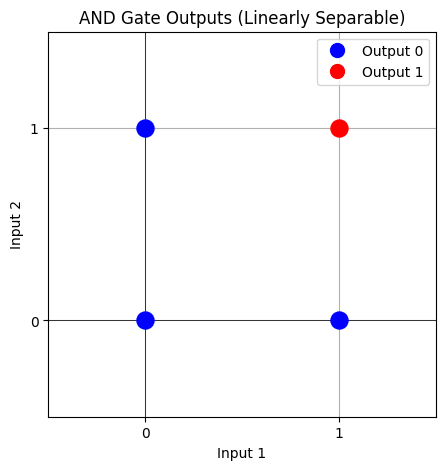

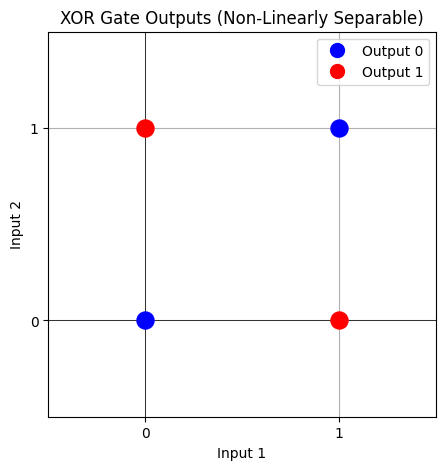

In [9]:
# Define the input points as a NumPy array for easier slicing
inputs = np.array([[0, 0], [0, 1],[1, 0], [1, 1]])
x_coords = inputs[:, 0]
y_coords = inputs[:, 1]

# Define the expected outputs
outputs_and = np.array([0, 0, 0, 1])
outputs_xor = np.array([0, 1, 1, 0])

# Colors map: Index 0 is blue, Index 1 is red
colors = ['blue', 'red']

def plot_gate(gate_outputs, title):
    plt.figure(figsize=(5, 5))
    plt.title(title)
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')

    # Plot each coordinate with the corresponding color based on its output
    for i in range(len(inputs)):
        plt.scatter(x_coords[i], y_coords[i], color=colors[gate_outputs[i]], s=150, zorder=3)

    plt.xticks([0, 1])
    plt.yticks([0, 1])
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.grid(True, zorder=0)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)

    # Create legend manually
    import matplotlib.lines as mlines
    blue_marker = mlines.Line2D([],[], color='blue', marker='o', linestyle='None', markersize=10, label='Output 0')
    red_marker = mlines.Line2D([],[], color='red', marker='o', linestyle='None', markersize=10, label='Output 1')
    plt.legend(handles=[blue_marker, red_marker], loc='best')

    plt.show()

# Execute plotting
plot_gate(outputs_and, 'AND Gate Outputs (Linearly Separable)')
plot_gate(outputs_xor, 'XOR Gate Outputs (Non-Linearly Separable)')

Part 2: Multi-Layer Networks with Keras - Solving XOR


In [13]:
import numpy as np

# XOR Dataset Formulation
X = np.array([[0, 0],[0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# XOR Dataset Formulation
X = np.array([[0, 0],[0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the input layer using keras.Input
inputs = keras.Input(shape=(2,), name="xor_input")

# Add Hidden Layer
x = layers.Dense(units=4, activation='relu', name="hidden_layer")(inputs)

# Add Output Layer
outputs = layers.Dense(units=1, activation='sigmoid', name="output_layer")(x)

# Create the Keras Model
model = keras.Model(inputs=inputs, outputs=outputs, name="MLP_XOR_Solver")

# Print structural overview
model.summary()

Model: "MLP_XOR_Solver"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xor_input (InputLayer)          │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer (Dense)            │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [14]:
# --- YOUR TASK: Define the number of epochs --- #
num_epochs = 1000 # Try 1000 to start
# --- END YOUR TASK --- #

history = model.fit(X, y, epochs=num_epochs, batch_size=4, verbose=0)
print(f"Final Training Accuracy: {history.history['accuracy'][-1] * 100}%")

Final Training Accuracy: 75.0%


In [11]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [15]:
predictions = (model.predict(X) > 0.5).astype(int)
for i in range(len(X)):
    print(f"Input: {X[i]}, Predicted: {int(predictions[i])}, Expected: {int(y[i])}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Input: [0. 0.], Predicted: 0, Expected: 0
Input: [0. 1.], Predicted: 0, Expected: 1
Input: [1. 0.], Predicted: 1, Expected: 1
Input: [1. 1.], Predicted: 0, Expected: 0


/tmp/ipykernel_3011/2976543718.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Input: {X[i]}, Predicted: {int(predictions[i])}, Expected: {int(y[i])}")


Beyond XOR - Visualizing Complex Decision Boundaries

In [16]:
# Generate synthetic circular data
np.random.seed(42)
X_circle = np.random.uniform(-2, 2, (400, 2)) # 400 random coordinates between -2 and 2
# Target: 1 if inside radius 1.2, else 0 (Equation of a circle: x^2 + y^2 = r^2)
y_circle = (X_circle[:, 0]**2 + X_circle[:, 1]**2 <= 1.2**2).astype(int)

# 1. Define Model (Adding an extra hidden layer for geometric complexity)
circle_model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# 2. Compile
circle_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train
print("Training on circular dataset...")
circle_model.fit(X_circle, y_circle, epochs=300, batch_size=16, verbose=0)
print("Training Complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training on circular dataset...
Training Complete.


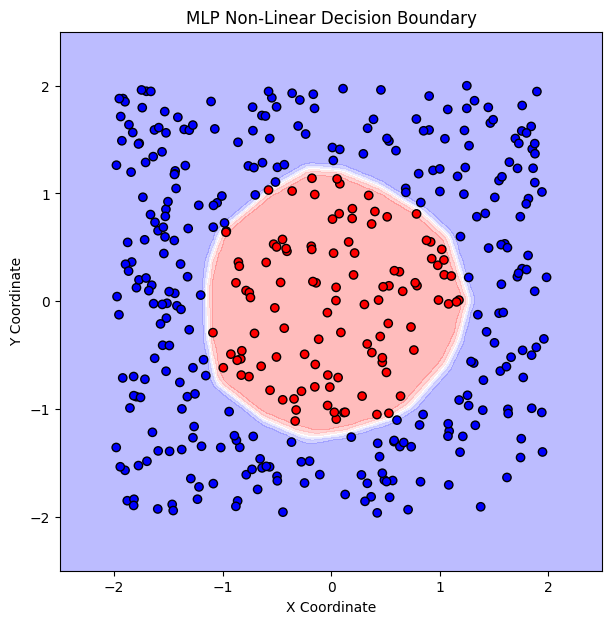

In [18]:
import matplotlib.pyplot as plt

# Create a dense grid of coordinates across the entire graph space
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 100), np.linspace(-2.5, 2.5, 100))

# Flatten the grid to feed into the model
grid_coordinates = np.c_[xx.ravel(), yy.ravel()]

# Predict the output for every single point on the grid
predictions = circle_model.predict(grid_coordinates, verbose=0)

# Reshape predictions back into the 2D grid shape
zz = predictions.reshape(xx.shape)

# Plotting the Decision Boundary
plt.figure(figsize=(7, 7))
plt.title("MLP Non-Linear Decision Boundary")

# plt.contourf colors the background based on the model's predictions
plt.contourf(xx, yy, zz, alpha=0.3, cmap='bwr')

# Plot the actual original dataset points on top
plt.scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle, cmap='bwr', edgecolor='k')

plt.xlim(-2.5, 2.5); plt.ylim(-2.5, 2.5)
plt.xlabel("X Coordinate"); plt.ylabel("Y Coordinate")
plt.show()